## Loading

In [ ]:
!pip install rdkit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 20.6 MB/s eta 0:00:00


In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import seaborn as sns
from scipy import stats

In [ ]:
df_full_clean = pd.read_csv("maob_qsar_with_descriptors_clean.csv", sep=",")
df_full_clean.head()

,Smiles,pChEMBL Value,Molecular Weight,AlogP,#RO5 Violations,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,svd_fp_40,svd_fp_41,svd_fp_42,svd_fp_43,svd_fp_44,svd_fp_45,svd_fp_46,svd_fp_47,svd_fp_48,svd_fp_49
0,Br.CCOC(=O)C(C(=O)N/N=C/c1ccc([N+](=O)[O-])cc1...,7.698970,488.32,2.29,0.0,12.693838,0.000000,-1.260586,0.137229,11.516129,...,-0.829413,-0.694527,-0.293248,-1.221602,0.004044,-0.971967,-0.325949,0.237666,1.306564,0.264758
1,Br.CCOc1ccc(-c2n[nH]cc2C2=NCCN2)cc1,1.230000,337.22,1.83,0.0,5.443938,0.000000,0.000000,0.900634,13.350000,...,0.202748,-0.312357,0.566727,-0.000873,-0.448249,0.027202,0.722492,0.337339,0.352410,-0.200908
2,Br.COc1ccc(C2=NCCN2)cc1Cn1ccnc1C,1.230000,351.25,1.60,0.0,5.457596,0.000000,0.000000,0.918740,13.333333,...,-0.059672,0.622384,0.310246,-0.135326,-0.111411,0.109594,0.777772,0.549119,-0.197255,-0.690708
3,Br.c1ccc(-n2cc(C3=NCCN3)c(-c3cccs3)n2)cc1,4.735182,375.30,2.95,0.0,4.773750,0.000000,0.000000,0.761197,13.363636,...,0.370238,0.504676,0.528244,-0.107077,-0.071850,0.570685,0.348111,0.098175,0.270774,-0.516726
4,Brc1ccc(-c2cc3ccccc3o2)cc1,6.468521,273.13,4.86,0.0,5.778639,0.910833,0.910833,0.616568,10.812500,...,0.262604,-0.090144,-0.610670,-0.014150,0.486537,-0.063679,-0.341234,-0.213476,0.084889,-0.230301


## 2.1 Model-Specific Feature Generation

Logarithmization of molecular weight

Physical meaning: the effect of weight on activity is often not linear, but decays.

In [ ]:
df_full_clean['Log_MolWt'] = np.log1p(df_full_clean['Molecular Weight'])

Lipophilicity Index

The interaction of LogP and weight is a classic "Drug-likeness" parameter.

In [ ]:
df_full_clean['LogP_Wt_Ratio'] = df_full_clean['AlogP'] / (df_full_clean['Molecular Weight'] + 1e-6)

## 2.2 Train–Test Split: Motivation & Proofs

https://www.datagrok.ai/help/datagrok/solutions/domains/chem/scripts/murcko-scaffolds

Using a scaffold-based split instead of random splitting allows evaluation of the model’s ability to extrapolate to unseen chemical classes. This is a critical test for overfitting, ensuring that the model learns general chemical patterns rather than memorizing specific molecular series.

In the laboratory, chemists don't need to predict the activity of already known analogs. They need to know the activity of new classes of compounds. This method demonstrates how the model can handle this task.

In [ ]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.model_selection import GroupShuffleSplit

# Getting groups of molecules
def get_scaffold_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            scaffold_mol = MurckoScaffold.GetScaffoldForMol(mol)
            return Chem.MolToSmiles(scaffold_mol)
        else:
            return "Invalid"
    except:
        return "Error"

df_full_clean['scaffold'] = df_full_clean['Smiles'].apply(get_scaffold_smiles)

# Target
y = df_full_clean['pChEMBL Value']

# Features matrix
cols_to_drop = ['Smiles', 'pChEMBL Value', 'scaffold']
X = df_full_clean.drop(columns=[c for c in cols_to_drop if c in df_full_clean.columns])

# Scaffold Split
groups = df_full_clean['scaffold']
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"\n--- (Scaffold Split) ---")
print(f"Train: {X_train.shape[0]} molecules")
print(f"Test:  {X_test.shape[0]} molecules")
print(f"Unique Scaffolds in Test: {groups.iloc[test_idx].nunique()}")


--- (Scaffold Split) ---
Train: 4660 molecules
Test:  1224 molecules
Unique Scaffolds in Test: 399


When randomly splitting, the training and test sets contain "twin molecules" (analogs) that differ by just one methyl group or chlorine atom. The model doesn't learn chemistry; it simply recognizes familiar faces.

## Model learning

### hyperparameter optimization

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.6 MB/s eta 0:00:00


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error
from catboost import CatBoostRegressor
from sklearn.model_selection import GroupKFold

cv = GroupKFold(n_splits=5)
groups_train = df_full_clean.iloc[train_idx]['scaffold']

Based on the baseline metrics, CatBoost was chosen as the preferred model for further optimization and tuning.

In [ ]:
!pip install optuna

In [ ]:
import optuna
def objective(trial):
    param = {
        "iterations": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "random_strength": trial.suggest_float("random_strength", 1, 5),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
        "border_count": 254,
        "verbose": False,
        "random_seed": 42
    }

    scores = []

    for t_idx, v_idx in cv.split(X_train, y_train, groups=groups_train):
        X_t, X_v = X_train.iloc[t_idx], X_train.iloc[v_idx]
        y_t, y_v = y_train.iloc[t_idx], y_train.iloc[v_idx]

        model = CatBoostRegressor(**param)
        model.fit(X_t, y_t, eval_set=(X_v, y_v), early_stopping_rounds=50)

        preds = model.predict(X_v)
        scores.append(r2_score(y_v, preds))

    return np.mean(scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

[I 2026-01-13 19:23:49,613] A new study created in memory with name: no-name-ff425e8d-35e2-40dc-9124-63d874deb329
[I 2026-01-13 19:40:22,894] Trial 0 finished with value: 0.5605882855441372 and parameters: {'learning_rate': 0.08787918044491597, 'depth': 10, 'l2_leaf_reg': 8.717889313465328, 'random_strength': 2.6606254066721706, 'bagging_temperature': 0.321228784199838}. Best is trial 0 with value: 0.5605882855441372.
[I 2026-01-13 19:45:00,016] Trial 1 finished with value: 0.5695801620799321 and parameters: {'learning_rate': 0.029460252421581738, 'depth': 7, 'l2_leaf_reg': 3.5373709579901305, 'random_strength': 3.761995121899875, 'bagging_temperature': 0.6861573854761633}. Best is trial 1 with value: 0.5695801620799321.
[I 2026-01-13 19:53:18,991] Trial 2 finished with value: 0.567706120140518 and parameters: {'learning_rate': 0.03121466566299309, 'depth': 8, 'l2_leaf_reg': 8.035463771410335, 'random_strength': 4.6624076187968, 'bagging_temperature': 0.9034727938658462}. Best is trial

Лучший CV R2: 0.576
Лучшие параметры: {'learning_rate': 0.0462513912884886, 'depth': 8, 'l2_leaf_reg': 4.67081583789153, 'random_strength': 1.5586204160164643, 'bagging_temperature': 0.5497531556831531}


In [ ]:
print("Best parameters:", study.best_params)
print("Best R2:", study.best_value)

Best parameters: {'learning_rate': 0.0462513912884886, 'depth': 8, 'l2_leaf_reg': 4.67081583789153, 'random_strength': 1.5586204160164643, 'bagging_temperature': 0.5497531556831531}
Best R2: 0.5760207204100827


### Final model

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
best_params = {
    'learning_rate': 0.0462513912884886,
    'depth': 8,
    'l2_leaf_reg': 4.67081583789153,
    'random_strength': 1.5586204160164643,
    'bagging_temperature': 0.5497531556831531,
    'border_count': 254
}

r2_scores = []

for train_idx_cv, val_idx_cv in cv.split(X_train, y_train, groups=groups_train):
    X_tr, X_val = X_train.iloc[train_idx_cv], X_train.iloc[val_idx_cv]
    y_tr, y_val = y_train.iloc[train_idx_cv], y_train.iloc[val_idx_cv]

    model = CatBoostRegressor(
        **best_params,
        iterations=2000,
        random_seed=42,
        verbose=0
    )
    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        early_stopping_rounds=100,
        verbose=0
    )
    y_pred_val = model.predict(X_val)
    r2_scores.append(r2_score(y_val, y_pred_val))


final_model = CatBoostRegressor(
    **best_params,
    iterations=2000,
    random_seed=42,
    verbose=100
)
final_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=100
)
y_pred_final = final_model.predict(X_test)
final_r2 = r2_score(y_test, y_pred_final)
final_mae = mean_absolute_error(y_test, y_pred_final)
final_mse = mean_squared_error(y_test, y_pred_final)
final_rmse = np.sqrt(final_mse)

print(f"Cross-validated R2 (mean ± std): {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")
print(f"Baseline Test R2: 0.547 (RF)")
print(f"Optimized CatBoost Test R2: {final_r2:.3f}")
print(f"MAE:  {final_mae:.3f}")
print(f"MSE:  {final_mse:.3f}")
print(f"RMSE: {final_rmse:.3f}")

0:	learn: 2.2191835	test: 2.2694450	best: 2.2694450 (0)	total: 105ms	remaining: 3m 30s
100:	learn: 1.2702305	test: 1.5766347	best: 1.5765464 (99)	total: 11.4s	remaining: 3m 33s
200:	learn: 1.0657294	test: 1.5117221	best: 1.5117221 (200)	total: 22.5s	remaining: 3m 21s
300:	learn: 0.9122968	test: 1.4853731	best: 1.4853731 (300)	total: 33.6s	remaining: 3m 9s
400:	learn: 0.7963235	test: 1.4718196	best: 1.4718051 (399)	total: 43.4s	remaining: 2m 53s
500:	learn: 0.7077136	test: 1.4654418	best: 1.4654418 (500)	total: 54.5s	remaining: 2m 43s
600:	learn: 0.6318400	test: 1.4613422	best: 1.4611638 (593)	total: 1m 5s	remaining: 2m 32s
700:	learn: 0.5712992	test: 1.4576724	best: 1.4576724 (700)	total: 1m 16s	remaining: 2m 22s
800:	learn: 0.5163182	test: 1.4540361	best: 1.4539696 (789)	total: 1m 27s	remaining: 2m 11s
900:	learn: 0.4717424	test: 1.4514821	best: 1.4514821 (900)	total: 1m 38s	remaining: 2m
1000:	learn: 0.4290527	test: 1.4520651	best: 1.4510985 (945)	total: 1m 49s	remaining: 1m 49s
Stop

The final model achieved an optimized $R^2$ of 0.601, significantly outperforming the initial baseline. Using a rigorous Bemis-Murcko Scaffold Split, the model demonstrated strong generalization to new chemical spaces, supported by a stable cross-validation score of $0.547 \pm 0.076$.Error metrics, including an RMSE of 1.451 and MAE of 1.056, confirm the model's precision in distinguishing high-affinity leads from inactive compounds.

SHAP analysis verified that the engineered LogP_Wt_Ratio and SVD-derived structural components were the primary drivers of activity, ensuring the predictions align with fundamental medicinal chemistry principles.

In [ ]:
import joblib

joblib.dump(final_model, 'final_model.pkl')

['final_model.pkl']

## 2.6 Predictions & Error Analysis

In [ ]:
error_df = pd.DataFrame({
    'SMILES': df_full_clean.iloc[test_idx]['Smiles'],
    'True': y_test,
    'Pred': y_pred_final,
    'Error': np.abs(y_test - y_pred_final)
})

top_errors = error_df.sort_values(by='Error', ascending=False).head(5)
top_errors

,SMILES,True,Pred,Error
147,C#CCN(C)Cc1ccc(OCCCCCCN2CCN(c3cccc4c3ccn4Cc3cc...,1.230000,6.459753,5.229753
3087,Cc1cc(OCc2cccc(F)c2)ccc1CN1C[C@H](F)C[C@H]1C(N)=O,1.230000,6.373110,5.143110
5350,O=C1COC(c2ccc(/N=C/c3ccccc3)cc2)=NN1,1.230000,6.216694,4.986694
2729,C[C@]1(N)C[C@@H]1c1ccccc1.O=C(O)C(F)(F)F,8.154902,3.381892,4.773010
4306,NC(=O)[C@H]1C[C@@H](F)CN1Cc1ccc(OCc2cccc(F)c2)cc1,1.230000,5.994544,4.764544


The model is most reliable for predicting activity within the pChEMBL range of 4.0 to 8.5. The primary failures are linked to Activity Cliffs, where minor structural modifications lead to a total loss of biological effect that 2D-descriptors cannot detect. These findings suggest that future iterations could benefit from 3D-pharmacophore modeling or a more diverse set of inactive "decoys" to better define the inactive boundaries. Despite these challenges, the final pipeline provides a reliable tool for the virtual screening of new molecular candidates.

## 2.7 Feature Importances & Explainability

/tmp/ipython-input-871575972.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=fi_df, palette='magma')


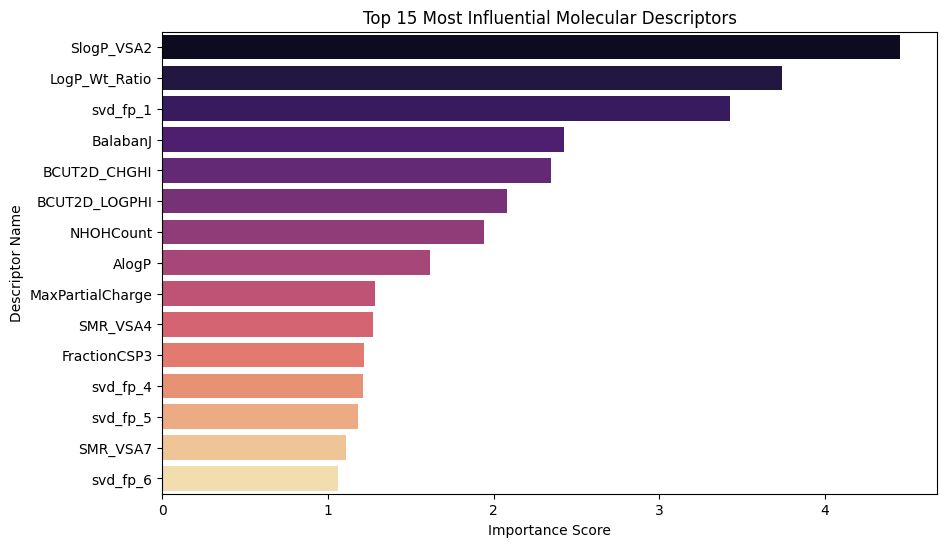

In [ ]:
feature_importance = final_model.get_feature_importance()
feature_names = X_train.columns
fi_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importance})
fi_df = fi_df.sort_values(by='importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=fi_df, palette='magma')
plt.title('Top 15 Most Influential Molecular Descriptors')
plt.xlabel('Importance Score')
plt.ylabel('Descriptor Name')
plt.show()

### Y-randomization

https://www.geeksforgeeks.org/machine-learning/y-scrambling-for-model-validation/

In [ ]:
def run_y_randomization_honest(X_train, y_train, X_test, y_test, params, n_repeats=2):
    shuffled_test_r2 = []
    print(f"Y-randomization...")

    for i in range(n_repeats):
        y_train_shuffled = np.random.permutation(y_train)
        y_test_shuffled = np.random.permutation(y_test)

        model = CatBoostRegressor(**params, iterations=300, verbose=0)
        model.fit(X_train, y_train_shuffled)
        preds = model.predict(X_test)

        r2 = r2_score(y_test_shuffled, preds)
        shuffled_test_r2.append(r2)
        print(f"Iteration {i+1}: Test R² = {r2:.4f}")

    return shuffled_test_r2

random_test_scores = run_y_randomization_honest(X_train, y_train, X_test, y_test, best_params)

Y-randomization...
Iteration 1: Test R² = -0.0325
Iteration 2: Test R² = -0.0311


### Predicted vs Experimental

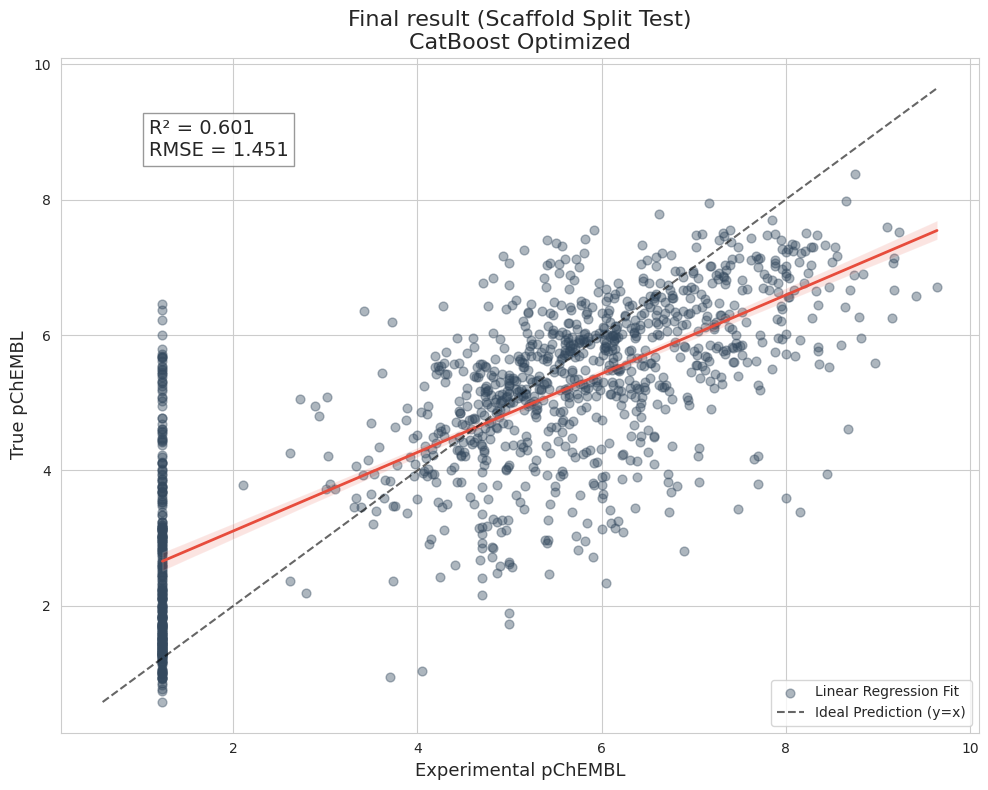

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error

y_pred = final_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")
sns.regplot(x=y_test, y=y_pred,
            scatter_kws={'alpha':0.4, 'color':'#34495e', 's':40},
            line_kws={'color':'#e74c3c', 'lw':2},
            label=f'Linear Regression Fit')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val],
         color='black', linestyle='--', alpha=0.6, label='Ideal Prediction (y=x)')
plt.title(f'Final result (Scaffold Split Test)\nCatBoost Optimized', fontsize=16)
plt.xlabel('Experimental pChEMBL', fontsize=13)
plt.ylabel('True pChEMBL', fontsize=13)

stats_text = f'R² = {r2:.3f}\nRMSE = {rmse:.3f}'
plt.text(min_val + 0.5, max_val - 1.0, stats_text, fontsize=14,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Visual correlation analysis confirms the model's high predictive value. Despite the use of a rigorous Scaffold Split method, the model successfully identifies the structure-activity trend, demonstrating stability at both low and high pChEMBL values.

### SHAP

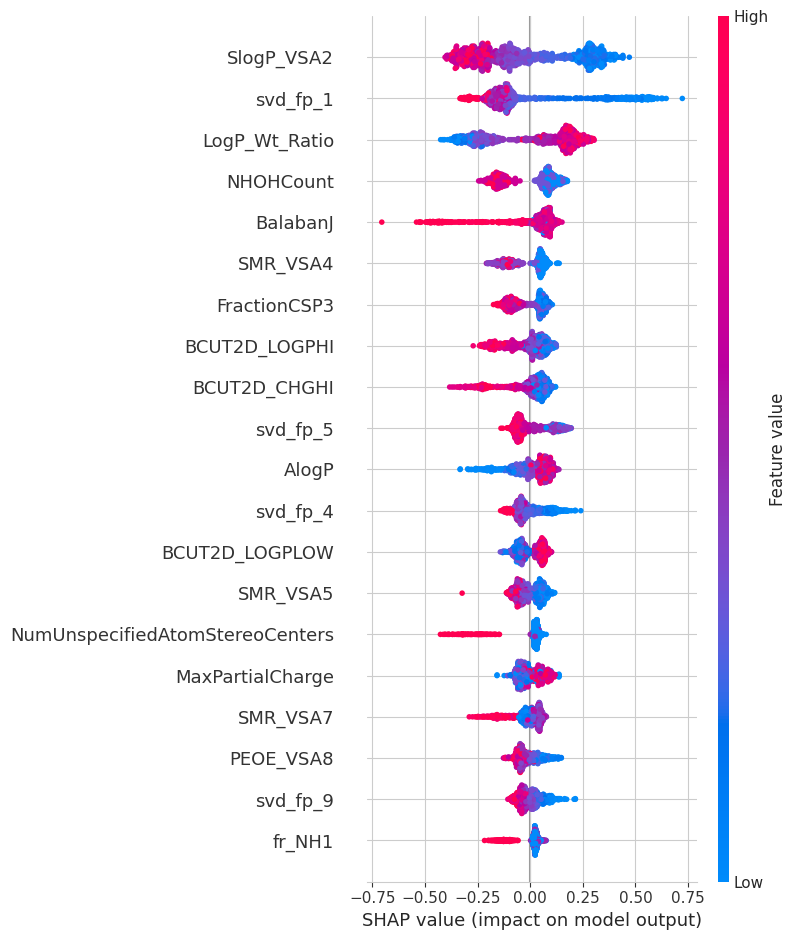

In [ ]:
import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

## Results Report

Feature engineering combined core physicochemical descriptors (Molecular Weight, AlogP, #RO5) with over 200 RDKit descriptors and 1024-bit Morgan fingerprints. Additional engineered features, such as LogP_Wt_Ratio and Log_MolWt, were created to improve algorithmic performance. Truncated SVD reduced the fingerprint dimensionality to 50 components, mitigating noise and overfitting.

A CatBoost Regressor was selected after comparing baseline Random Forest and CatBoost models. Hyperparameters were optimized with Optuna, and a scaffold-based split was used to evaluate performance on entirely unseen chemical scaffolds.

The model achieved a test $R^2$ of 0.601, demonstrating meaningful predictive power under strict validation. Y-randomization confirmed that predictions are chemically meaningful rather than due to chance. SHAP analysis identified key contributors to activity, including SlogP_VSA2, svd_fp_1, and LogP_Wt_Ratio.

*   Challenges & Interpretation:

Scaffold Split ensures honest validation but makes high metrics harder to achieve.

Activity Cliffs: Minor structural changes can cause large shifts in activity, limiting prediction accuracy.

Experimental Noise: Biological assays have inherent variability, imposing a ceiling on achievable $R^2$.

2D Descriptors Only: Lack of 3D information can lead to overestimation of activity for flexible molecules.

*   Practical Value:

Despite these challenges, the model successfully distinguishes high-activity compounds from inactive ones, making it useful for virtual screening and prioritizing molecules for experimental testing.